# Задача
В этой работе вам предлагается решить задачу регрессии, а именно построить алгоритм, определяющий качество вина на основе физико-химических тестов:
 - fixed acidity
 - volatile acidity
 - citric acid
 - residual sugar
 - chlorides
 - free sulfur dioxide
 - total sulfur dioxide
 - density
 - pH
 - sulphates
 - alcohol 
 
Более подробно про признаки можно почитать [здесь](https://archive.ics.uci.edu/ml/datasets/wine+quality). Целевой признак записан в переменной *quality*.

В этой задаче для обучения будут использовать 2 алгоритма:
- [DecisonTree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)
- [AdaBoostRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostRegressor.html#sklearn.ensemble.AdaBoostRegressor)

# Решение

Загрузите набор данных *winequality-red.csv* с помощью `pandas` (скачать можно [здесь](https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv), или с помощью скрипта ниже). Чтобы лучше понимать, с чем вы работаете/корректно ли вы загрузили данные можно вывести несколько первых строк на экран.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_style("whitegrid")

In [3]:
RANDOM_STATE = 151
ADA_RANDOM_STATE = 12
DECISION_TREE_RANDOM_STATE = 1

In [4]:
df = pd.read_csv("winequality-red.csv", sep=";")

## Анализ и предобработка данных

Обычно после загрузки датасета всегда необходима его некоторая предобработка. В данном случае она будет заключаться в следующем: 
1. Проверьте есть ли в данных пропущенные значения. Удалите из выборки все объекты с пропусками и дубликаты.
2. Выделите 70% выборки для обучения и дальнейшего анализа.
3. Проанализируйте признаки и по необходимости предобработайте их. Все шаги предобработки поясните текстом.
4. Целевую переменную (ту, которую мы хотим предсказывать) можно выделить в отдельную переменную (НЕ забудьте удалить ее из датасета, когда будете обучать модель).

In [5]:
# Посмотрим в целом на датасет
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
# Посмотрим, есть ли пропуски (нет)
df.isnull().any()

fixed acidity           False
volatile acidity        False
citric acid             False
residual sugar          False
chlorides               False
free sulfur dioxide     False
total sulfur dioxide    False
density                 False
pH                      False
sulphates               False
alcohol                 False
quality                 False
dtype: bool

In [7]:
# Пропусков нет, однако есть дубликаты (240 штук)

In [8]:
n1 = len(df)
df.drop_duplicates(keep="first", inplace=True)
n2 = len(df)
n1-n2

240

In [9]:
# Все переменные 'своего' формата, можно ничего не конвертировать
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1359 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1359 non-null   float64
 1   volatile acidity      1359 non-null   float64
 2   citric acid           1359 non-null   float64
 3   residual sugar        1359 non-null   float64
 4   chlorides             1359 non-null   float64
 5   free sulfur dioxide   1359 non-null   float64
 6   total sulfur dioxide  1359 non-null   float64
 7   density               1359 non-null   float64
 8   pH                    1359 non-null   float64
 9   sulphates             1359 non-null   float64
 10  alcohol               1359 non-null   float64
 11  quality               1359 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 138.0 KB


In [10]:
df.quality.unique()

array([5, 6, 7, 4, 8, 3])

<Axes: ylabel='quality'>

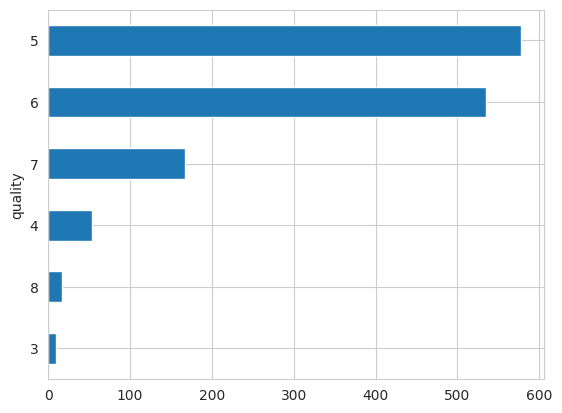

In [11]:
# Прежде, чем делить на трейн/тест, посмотрим на целевой признак
df["quality"].value_counts().sort_values().plot(kind='barh')

Видим, что целевая переменная quality принимает лишь 6 значений. Из [описания датасета](https://archive.ics.uci.edu/dataset/186/wine+quality) известно, что целевой признак принимает значения от 0 до 10. Надо полоагать, остальные признаки присутствуют во второй части датасета (winequality-white.csv).

In [12]:
# Посмотрим в целом на датасет. Можно заметить, что у некоторых признаков (free sulfur dioxide, total sulfur dioxide)
# достаточно большой разброс данных, что может свидетельствовать о наличии выбросов
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1359.0,8.310596,1.736990,4.60000,7.1000,7.9000,9.20000,15.90000
volatile acidity,1359.0,0.529478,0.183031,0.12000,0.3900,0.5200,0.64000,1.58000
citric acid,1359.0,0.272333,0.195537,0.00000,0.0900,0.2600,0.43000,1.00000
residual sugar,1359.0,2.523400,1.352314,0.90000,1.9000,2.2000,2.60000,15.50000
chlorides,1359.0,0.088124,0.049377,0.01200,0.0700,0.0790,0.09100,0.61100
free sulfur dioxide,1359.0,15.893304,10.447270,1.00000,7.0000,14.0000,21.00000,72.00000
total sulfur dioxide,1359.0,46.825975,33.408946,6.00000,22.0000,38.0000,63.00000,289.00000
density,1359.0,0.996709,0.001869,0.99007,0.9956,0.9967,0.99782,1.00369
pH,1359.0,3.309787,0.155036,2.74000,3.2100,3.3100,3.40000,4.01000
sulphates,1359.0,0.658705,0.170667,0.33000,0.5500,0.6200,0.73000,2.00000


<Axes: xlabel='quality', ylabel='residual sugar'>

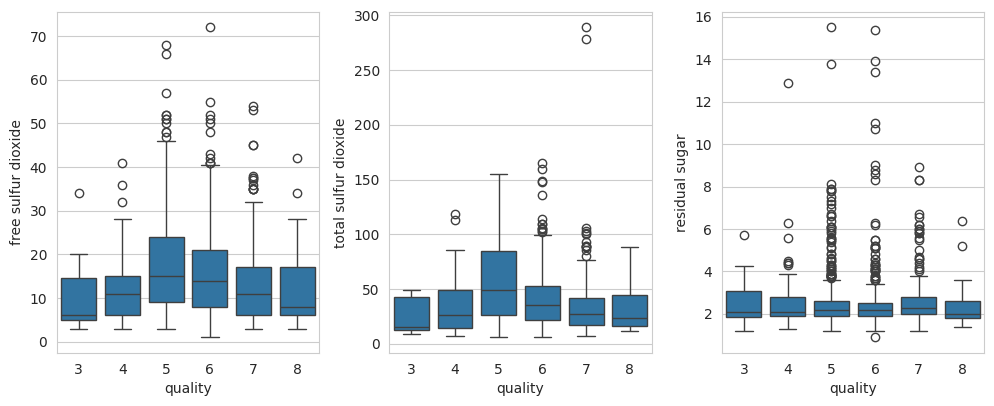

In [13]:
fig, axs = plt.subplots(1,3, figsize=(10, 4))
fig.tight_layout(w_pad=2)

sns.boxplot(data=df, x='quality', y='free sulfur dioxide', ax=axs[0])
sns.boxplot(data=df, x='quality', y='total sulfur dioxide', ax=axs[1])
sns.boxplot(data=df, x='quality', y='residual sugar', ax=axs[2])

## Обучение модели регрессии

Постройте модель регрессии, используя 2 алгоритма:
- [DecisonTree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)
- [AdaBoostRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostRegressor.html#sklearn.ensemble.AdaBoostRegressor)

Для начала используйте гиперпараметры по умолчанию.

Рассчитайте среднее качество кросс-валидации модели как долю дисперсии зависимой переменной (коэффициент детерминации) $R^2$. Каким получилось качество? Какой алгоритм вы бы выбрали для дальнейшей работы? Обоснуйте свой выбор.

In [14]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [15]:
def train_tree(x_train, x_test, y_train, y_test, params={}, **kwargs):
    """
    Функция обучения модели DecisionTreeRegressor
    
    x_train - обучающая выборка
    x_test - тестовая выборка
    y_train - значение целевого признака тренировочного набора
    y_test - значение целевого признака тестового набора
    params - словарь параметров модели
    
    Returns:
        функция возвращаеь саму модель и предсказания на тестовом наборе данных
    """
    if params.get('random_state') is None:
        params['random_state'] = DECISION_TREE_RANDOM_STATE
        
    tree = DecisionTreeRegressor(**params)
    tree.fit(x_train, y_train)
    y_pred = tree.predict(x_test)
    
    model_name = kwargs.get('model_name')
    if model_name is None:
        model_name = 'tree'
        
    res = pd.DataFrame({
        'model': [model_name],
        'mse': [mean_squared_error(y_test, y_pred)],
        'r2': [r2_score(y_test, y_pred)],
        'model_params': [kwargs.get('model_params')],
        'ds_info': [kwargs.get('ds_info')]
    })
    return tree, res

In [16]:
def train_ada_boost_regr(x_train, x_test, y_train, y_test, params={}, **kwargs):
    """
    Функция обучения модели AdaBoostRegressor
    
    x_train - обучающая выборка
    x_test - тестовая выборка
    y_train - значение целевого признака тренировочного набора
    y_test - значение целевого признака тестового набора
    params - словарь параметров модели
    
    Returns:
        функция возвращаеь саму модель и предсказания на тестовом наборе данных
    """
    if params.get('random_state') is None:
        params['random_state'] = ADA_RANDOM_STATE
        
    ada = AdaBoostRegressor(**params)
    ada.fit(x_train, y_train)
    y_pred = ada.predict(x_test)

    model_name = kwargs.get('model_name')
    if model_name is None:
        model_name = 'ada'
        
    res = pd.DataFrame({
        'model': [model_name],
        'mse': [mean_squared_error(y_test, y_pred)],
        'r2': [r2_score(y_test, y_pred)],
        'model_params': [kwargs.get('model_params')],
        'ds_info': [kwargs.get('ds_info')]
    })
    return ada, res

In [17]:
# Датасет очень несбалансированный, при разбиении датасета есть смысл использовать стратификацию
df = pd.read_csv("winequality-red.csv", sep=";")
df.drop_duplicates(keep="first", inplace=True)

X = df.drop(columns="quality").values
y = df["quality"].values

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)

#### DecisionTreeRegressor
Обучим модель с параметрами по умолчанию, ничего не делая с данными

In [19]:
# Обучим простое дерево регрессии с параметрами по умолчанию

In [20]:
_, tree_res_0 = train_tree(
    X_train, X_test, y_train, y_test, model_params='default', ds_info='no_preprocess'
)

tree_res_0

,model,mse,r2,model_params,ds_info
0,tree,0.65625,-0.012218,default,no_preprocess


In [21]:
# MSE для предсказания с помощью простого усреднения
y_mean = y_train.mean()
y_pred_mean = [y_mean for _ in range(len(y_test))]
mean_squared_error(y_test, y_pred_mean)

0.6483297425410951

#### AdaBoostRegressor
Обучим модель с параметрами по умолчанию, ничего не делая с данными

In [22]:
# Теперь обучим модель AdaBoostRegressor с параметрами по умолчанию
_, ada_res_0 = train_ada_boost_regr(
    X_train, X_test, y_train, y_test, 
    model_params='default', ds_info='no_preprocess'
)

ada_res_0

,model,mse,r2,model_params,ds_info
0,ada,0.374586,0.422228,default,no_preprocess


In [23]:
# значение 0.42 не слишком высокое, однако модель AdaBoostRegressor умеет объяснять примерно 42% дисперсии, что
# гораздо лучше, чем просто дерево регрессии

#### Предобработка
В данных явно есть выбросы. К сожалению, нам неизвестна их природа - ошибка измерения, человеческий фактор или же это действительные значения, которые не вписываются в общую картину. Попробуем заменить выбросы на медианные значения

In [24]:
def replace_outlier_with_median(data, feature, trsh=0.95):
    """
    :param df: pd.DataFrame
    :param feature: feature to check for outliers
    :param trsh: quantile threshold
    :return: dataset with replaced values
    """
    median = data[feature].median()
    outlier_ind = data[data[feature] > data[feature].quantile(trsh)].index
    data[feature].loc[outlier_ind] = median
    return df

In [25]:
df = pd.read_csv("winequality-red.csv", sep=";")
df.drop_duplicates(keep="first", inplace=True)

X = df.drop(columns="quality").values
y = df["quality"].values

In [26]:
df = replace_outlier_with_median(df, 'total sulfur dioxide', trsh=0.9)
df = replace_outlier_with_median(df, 'free sulfur dioxide', trsh=0.9)
df = replace_outlier_with_median(df, 'residual sugar', trsh=0.9)

<Axes: xlabel='quality', ylabel='residual sugar'>

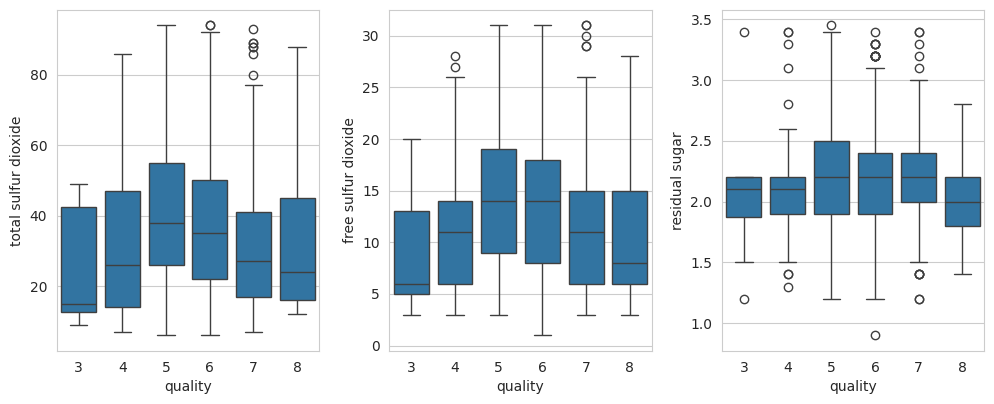

In [27]:
fig, axs = plt.subplots(1,3, figsize=(10, 4))
fig.tight_layout(w_pad=2)
sns.boxplot(data=df, x='quality', y='total sulfur dioxide', ax=axs[0])
sns.boxplot(data=df, x='quality', y='free sulfur dioxide', ax=axs[1])
sns.boxplot(data=df, x='quality', y='residual sugar', ax=axs[2])

Данные выглядят лучше, по крайней мере нет сильных выбросов. Попробуем еще раз обучить наши модели

In [28]:
X = df.drop(columns="quality").values
y = df["quality"].values

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)

#### DecisionTreeRegressor

In [30]:
_, tree_res_1 = train_tree(
    X_train, X_test, y_train, y_test, 
    model_params='default', ds_info='clean_outliers'
)

tree_res_1

,model,mse,r2,model_params,ds_info
0,tree,0.865196,-0.279576,default,clean_outliers


In [31]:
# Полученный коэффициент детерминации говорит, что модель работает хуже, чем простое среднее (убедимся в этом ниже)

In [32]:
# MSE для предсказания с помощью модели
# mean_squared_error(y_test, tree_pred)

In [33]:
# MSE для предсказания с помощью простого усреднения
y_mean = y_train.mean()
y_pred_mean = [y_mean for _ in range(len(y_test))]
mean_squared_error(y_test, y_pred_mean)

0.6761592186755785

#### AdaBoostRegressor

In [34]:
_, ada_res_1 = train_ada_boost_regr(
    X_train, X_test, y_train, y_test, 
    model_params='default', ds_info='clean_outliers'
)

ada_res_1

,model,mse,r2,model_params,ds_info
0,ada,0.468448,0.307191,default,clean_outliers


In [35]:
# Попытка устранить выбросы сделала только хуже. Возможно, это действительные данные и их наличие 
# даже помогает построить дерево (т.к. часть данных легко изолировать)

#### Конструирование признаков

Попытки убрать выбросы не дали особого результата. Также отметим, что вероятно с данными все хорошо и 
такие большие значения даже помогут лушче разделить признаковое пространство. Попробуем еще один метод - сгененрируем новые признаки. Возможно, взаимодействие некоторых признаков может дать новый информативный признак.

In [36]:
from sklearn.preprocessing import PolynomialFeatures

In [37]:
df = pd.read_csv("winequality-red.csv", sep=";")
df.drop_duplicates(keep="first", inplace=True)

X = df.drop(columns="quality").values
y = df["quality"].values

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)

In [39]:
poly = PolynomialFeatures(interaction_only=True)

In [40]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [41]:
_, tree_res_2 = train_tree(
    X_train, X_test, y_train, y_test, 
    model_params='default', ds_info='feature_interaction'
)

tree_res_2

,model,mse,r2,model_params,ds_info
0,tree,0.818627,-0.210704,default,feature_interaction


In [42]:
_, ada_res_2 = train_ada_boost_regr(
    X_train, X_test, y_train, y_test, 
    model_params='default', ds_info='feature_interaction'
)

ada_res_2

,model,mse,r2,model_params,ds_info
0,ada,0.452218,0.331194,default,feature_interaction


In [43]:
res = pd.concat((tree_res_0, ada_res_0, tree_res_1, ada_res_1, tree_res_2, ada_res_2))

In [44]:
res

,model,mse,r2,model_params,ds_info
0,tree,0.656250,-0.012218,default,no_preprocess
0,ada,0.374586,0.422228,default,no_preprocess
0,tree,0.865196,-0.279576,default,clean_outliers
0,ada,0.468448,0.307191,default,clean_outliers
0,tree,0.818627,-0.210704,default,feature_interaction
0,ada,0.452218,0.331194,default,feature_interaction


##### Вывод: 
Из коробки модель дерева регрессии не заработала совсем, её результаты оказались хуже, чем простое усреднение.  AdaBoostRegressor показывает гораздо лучшие метрики MSE и $R^2$, однако модель нуждается в дальнейшей настройке. Удаления выбросов сделало только хуже, а конструирование новых признаков не принесло результата.

Для дальнейших экспериментов предпочтительнее выбрать асамблевую модель AdaBoostRegressor, т.к. она показывает лучшие результаты по сравнению с простым деревом.

In [45]:
# --------------------------------------------------------------------------------------------------------------

Теперь сделаем подбор оптимальных гиперпараметров. Сделайте поиск по сетке с помощью кросс-валидации. Изменилось ли качество алгоритмов? Почему?

##### Обучение DecisionTreeRegressor

In [46]:
from sklearn.model_selection import GridSearchCV
import numpy as np

In [47]:
df = pd.read_csv("winequality-red.csv", sep=";")
df.drop_duplicates(keep="first", inplace=True)

X = df.drop(columns="quality").values
y = df["quality"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)

In [48]:
# Будем искать параметры модели с помощью рештчатого поиска с кросс-валидацией

In [49]:
tree_parameters = {
    'max_depth': np.arange(2, 6),
    'min_samples_split': np.arange(2,10), 
    'min_samples_leaf': np.arange(1,20),
    'min_weight_fraction_leaf': np.arange(0,0.6,0.1),
    'max_features': ['sqrt', 'log2', None],
    'max_leaf_nodes': np.arange(5,20),
    'random_state': [DECISION_TREE_RANDOM_STATE]
}

In [50]:
tree_gs = GridSearchCV(DecisionTreeRegressor(), tree_parameters, verbose=1, pre_dispatch=5, n_jobs=5)

In [51]:
tree_gs.fit(X_train, y_train)

Fitting 5 folds for each of 164160 candidates, totalling 820800 fits


GridSearchCV(estimator=DecisionTreeRegressor(), n_jobs=5,
             param_grid={'max_depth': array([2, 3, 4, 5]),
                         'max_features': ['sqrt', 'log2', None],
                         'max_leaf_nodes': array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]),
                         'min_samples_leaf': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                         'min_samples_split': array([2, 3, 4, 5, 6, 7, 8, 9]),
                         'min_weight_fraction_leaf': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5]),
                         'random_state': [1]},
             pre_dispatch=5, verbose=1)

In [52]:
# Посмотрим на лучшие параметры
tree_gs.best_params_

{'max_depth': 5,
 'max_features': None,
 'max_leaf_nodes': 14,
 'min_samples_leaf': 19,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 1}

In [53]:
# Обучим модель на лучших найденных гиперпараметрах
tree, tree_res_3 = train_tree(
    X_train, X_test, y_train, y_test, params=tree_gs.best_params_, 
    model_params='grid_search', ds_info='no_preprocess'
)

tree_res_3

,model,mse,r2,model_params,ds_info
0,tree,0.530498,0.215423,grid_search,no_preprocess


In [54]:
tree_poly_gs = GridSearchCV(DecisionTreeRegressor(), tree_parameters, pre_dispatch=5, n_jobs=5)

In [55]:
tree_poly_gs.fit(X_train_poly, y_train)

GridSearchCV(estimator=DecisionTreeRegressor(), n_jobs=5,
             param_grid={'max_depth': array([2, 3, 4, 5]),
                         'max_features': ['sqrt', 'log2', None],
                         'max_leaf_nodes': array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]),
                         'min_samples_leaf': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                         'min_samples_split': array([2, 3, 4, 5, 6, 7, 8, 9]),
                         'min_weight_fraction_leaf': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5]),
                         'random_state': [1]},
             pre_dispatch=5)

In [56]:
tree_poly_gs.best_params_

{'max_depth': 4,
 'max_features': None,
 'max_leaf_nodes': 8,
 'min_samples_leaf': 17,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 1}

In [57]:
# Обучим модель на лучших найденных гиперпараметрах
_, tree_res_4 = train_tree(
    X_train_poly, X_test_poly, y_train, y_test, params=tree_poly_gs.best_params_, 
    model_params='grid_search', ds_info='feature_interaction'
)

tree_res_4

,model,mse,r2,model_params,ds_info
0,tree,0.518203,0.233607,grid_search,feature_interaction


##### Обучение AdaBoostRegressor

In [58]:
ada_boost_parameters = {
    'n_estimators': np.arange(2, 65), 
    'learning_rate': np.arange(0.1, 2, 0.1), 
    'loss': ['linear', 'square', 'exponential'],
    'random_state': [ADA_RANDOM_STATE]
}

In [59]:
ada_boost_gs = GridSearchCV(AdaBoostRegressor(), ada_boost_parameters, pre_dispatch=5, n_jobs=5)

In [60]:
ada_boost_gs.fit(X_train, y_train)

GridSearchCV(estimator=AdaBoostRegressor(), n_jobs=5,
             param_grid={'learning_rate': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3,
       1.4, 1.5, 1.6, 1.7, 1.8, 1.9]),
                         'loss': ['linear', 'square', 'exponential'],
                         'n_estimators': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52,
       53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64]),
                         'random_state': [12]},
             pre_dispatch=5)

In [61]:
ada_boost_gs.best_params_

{'learning_rate': 0.9,
 'loss': 'linear',
 'n_estimators': 24,
 'random_state': 12}

In [62]:
ada, ada_res_3 = train_ada_boost_regr(
    X_train, X_test, y_train, y_test, params=ada_boost_gs.best_params_,
    model_params='grid_search', ds_info='no_preprocess'
)

ada_res_3

,model,mse,r2,model_params,ds_info
0,ada,0.456478,0.324894,grid_search,no_preprocess


In [63]:
# Обучим AdaBoostRegressor на выборке со взаимодействиями признаков

In [64]:
ada_poly_gs = GridSearchCV(AdaBoostRegressor(), ada_boost_parameters, pre_dispatch=5, n_jobs=5)
ada_poly_gs.fit(X_train_poly, y_train)

GridSearchCV(estimator=AdaBoostRegressor(), n_jobs=5,
             param_grid={'learning_rate': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3,
       1.4, 1.5, 1.6, 1.7, 1.8, 1.9]),
                         'loss': ['linear', 'square', 'exponential'],
                         'n_estimators': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52,
       53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64]),
                         'random_state': [12]},
             pre_dispatch=5)

In [65]:
ada_poly_gs.best_params_

{'learning_rate': 1.5000000000000002,
 'loss': 'linear',
 'n_estimators': 12,
 'random_state': 12}

In [66]:
_, ada_res_4 = train_ada_boost_regr(
    X_train_poly, X_test_poly, y_train, y_test, params=ada_poly_gs.best_params_,
    model_params='grid_search', ds_info='feature_interaction'
)

ada_res_4

,model,mse,r2,model_params,ds_info
0,ada,0.462978,0.315282,grid_search,feature_interaction


In [67]:
res = pd.concat((res, tree_res_3, tree_res_4, ada_res_3, ada_res_4))

In [68]:
res

,model,mse,r2,model_params,ds_info
0,tree,0.656250,-0.012218,default,no_preprocess
0,ada,0.374586,0.422228,default,no_preprocess
0,tree,0.865196,-0.279576,default,clean_outliers
0,ada,0.468448,0.307191,default,clean_outliers
0,tree,0.818627,-0.210704,default,feature_interaction
0,ada,0.452218,0.331194,default,feature_interaction
0,tree,0.530498,0.215423,grid_search,no_preprocess
0,tree,0.518203,0.233607,grid_search,feature_interaction
0,ada,0.456478,0.324894,grid_search,no_preprocess
0,ada,0.462978,0.315282,grid_search,feature_interaction


Оцените скорость обучения каждого из алгоритмов. Для этого воспользуйтесь графиком вида "ящик с усами", который отражает среднее время обучения алгоритма при фиксированном значении гиперпараметров. Что вы можете сказать о скорости работы алгоритмов? Почему наблюдаются такие результаты? Можно ли ускорить? Если да, то каким образом?

In [69]:
def learn_time(model, params, x, y, n):
    """
    Функция возвращает список времени обучения модели, сек
    """
    import time
    time_ = []
    model_instance = model(**params)
    for _ in range(n):    
        t1 = time.time()
        model_instance.fit(x,y)
        t2 = time.time()
        time_.append(t2-t1)
    return time_

In [70]:
# С помощью функции learn_time обучим модели 1000 раз на одних и тех же параметрах и оцеим скорость обучения
tree_time = learn_time(DecisionTreeRegressor, tree_gs.best_params_, X_train, y_train, n=1000)
ada_time = learn_time(AdaBoostRegressor, ada_boost_gs.best_params_, X_train, y_train, n=1000)

In [71]:
learn_alg_times = pd.DataFrame({
    "DecisionTreeRegressor": tree_time,
    "AdaBoostRegressor": ada_time
})

In [72]:
learn_alg_times["DecisionTreeRegressor"] *= 1000
learn_alg_times["AdaBoostRegressor"] *= 1000

In [73]:
learn_alg_times.head()

,DecisionTreeRegressor,AdaBoostRegressor
0,2.892971,47.085524
1,2.700806,46.919823
2,2.629757,48.291683
3,2.578735,46.806574
4,2.447605,46.835423


<Axes: xlabel='AdaBoostRegressor', ylabel='Learn time, ms'>

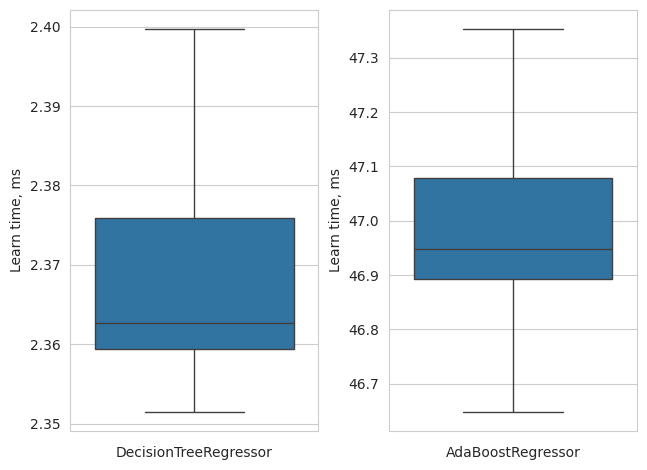

In [74]:
fig, axs = plt.subplots(1, 2)
fig.tight_layout(w_pad=2)

axs[0].set_ylabel("Learn time, ms")
axs[0].set_xlabel("DecisionTreeRegressor")
axs[1].set_ylabel("Learn time, ms")
axs[1].set_xlabel("AdaBoostRegressor")

sns.boxplot(
    y='DecisionTreeRegressor', 
    data=learn_alg_times, 
    showfliers=False,
    ax=axs[0]
)

sns.boxplot(
    y='AdaBoostRegressor', 
    data=learn_alg_times, 
    showfliers=False,
    ax=axs[1]
)

In [75]:
rate = learn_alg_times.AdaBoostRegressor.mean() / learn_alg_times.DecisionTreeRegressor.mean()
rate

19.671442853812486

In [76]:
y_pred_tree = tree.predict(X_test)
y_pred_ada  = ada.predict(X_test)

Text(0.5, 1.0, 'AdaBoostRegressor')

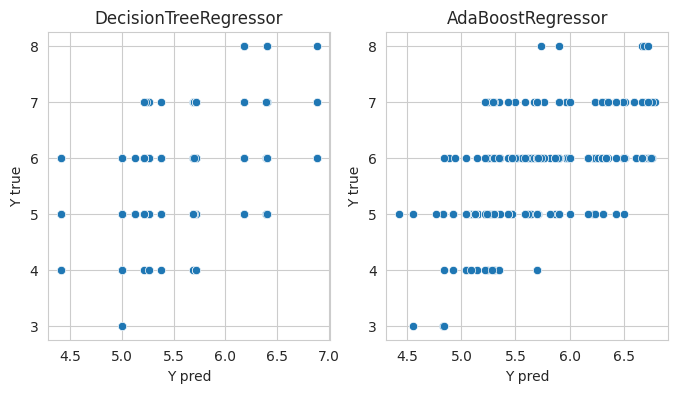

In [77]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))  
sns.scatterplot(x = y_pred_tree, y = y_test, ax=ax[0])
sns.scatterplot(x = y_pred_ada, y = y_test, ax=ax[1])
ax[0].grid(True)
ax[0].set_xlabel('Y pred')
ax[0].set_ylabel('Y true')
ax[0].set_title('DecisionTreeRegressor')

ax[1].grid(True)
ax[1].set_xlabel('Y pred')
ax[1].set_ylabel('Y true')
ax[1].set_title('AdaBoostRegressor')

Из графика видим, что AdaBoostRegressor работает ~20 раз медленнее. Это ожидаемый результат, т.к. это ансамблевый метод, обучающий "под капотом" множество деревьев (в данном случае 24), причем деревья обучаются последовательно. Отметим также, что скорость обучения очень зависит от количества моделей в ансамбле.

Можно предложить следующие способы ускорить обучение:
* использовать такие библиотеки/расширения как cuML, scikit-learn-intelex
* снизить размерность данных

## PCA преобразование

Теперь попробуем сделать преобразрование данных с помощью PCA. Выберите оптимальное количество компонент и преобразуйте данные. Объясните свой выбор.

In [78]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline

In [79]:
for n in range(2, X_train.shape[1]):
    pipe = Pipeline([('scale', StandardScaler()), ('pca', PCA(n_components=n))])
    pipe.fit(X_train)
    pprint(f'N components: {n}, explained var ratio: {pipe['pca'].explained_variance_ratio_.sum().round(3)}')

'N components: 2, explained var ratio: 0.457'
'N components: 3, explained var ratio: 0.602'
'N components: 4, explained var ratio: 0.713'
'N components: 5, explained var ratio: 0.797'
'N components: 6, explained var ratio: 0.855'
'N components: 7, explained var ratio: 0.909'
'N components: 8, explained var ratio: 0.947'
'N components: 9, explained var ratio: 0.979'
'N components: 10, explained var ratio: 0.995'


Видим, что 8 компонент объясняют 94% всей дисперсии, что должно хватить успешного обучения модели.

## Обучение моделей на данных, трансформированных с помощью PCA

Обучим те же классификаторы на трансформированных с помощью PCA данных. Подберите оптимальные значения исследуемых гиперпараметров для новых данных. Какой алгоритм справился лучше? Какой быстрее? Почему?

In [80]:
# перед использованием PCA данные необходимо отмасштабировать
n_components = 8
preprocess_pipe = make_pipeline(StandardScaler(), PCA(n_components=n_components))
preprocess_pipe.fit(X_train)

X_train_transformed = preprocess_pipe.fit_transform(X_train)
X_test_transformed = preprocess_pipe.transform(X_test)

In [81]:
# Построим тепловую карту главных компонент - посмотреть, как признаки входят в компоненты

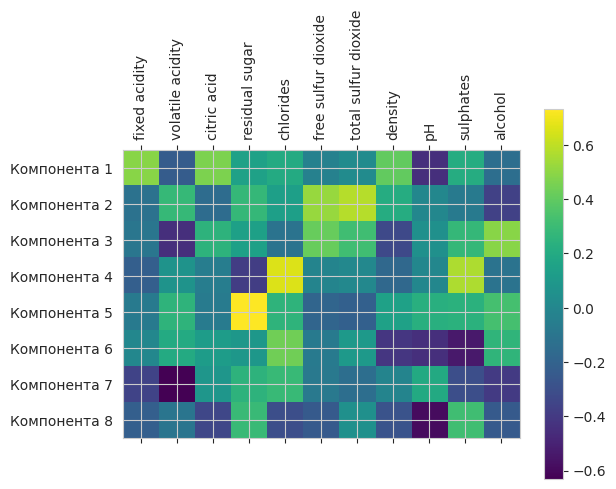

In [82]:
columns = [feature_name for feature_name in df.columns if feature_name != 'quality']
fig, ax = plt.subplots()

im = ax.matshow(preprocess_pipe.named_steps['pca'].components_, cmap='viridis')
ax.set_yticks(np.arange(0,n_components), [f"Компонента {i}" for i in range(1, n_components+1)])
ax.set_xticks(np.arange(len(columns)), columns, rotation=90)
plt.colorbar(im, ax=ax)

##### Обучение DecisionTreeRegressor на пространстве меньшей размерности

In [83]:
# Применим еще раз решетчатый поиск - будем перебирать те же параметры, но на преобразованных данных
tree_pca_gs = GridSearchCV(DecisionTreeRegressor(), tree_parameters, pre_dispatch=5, n_jobs=5)

In [84]:
tree_pca_gs.fit(X_train_transformed, y_train)

GridSearchCV(estimator=DecisionTreeRegressor(), n_jobs=5,
             param_grid={'max_depth': array([2, 3, 4, 5]),
                         'max_features': ['sqrt', 'log2', None],
                         'max_leaf_nodes': array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]),
                         'min_samples_leaf': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                         'min_samples_split': array([2, 3, 4, 5, 6, 7, 8, 9]),
                         'min_weight_fraction_leaf': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5]),
                         'random_state': [1]},
             pre_dispatch=5)

In [85]:
tree_pca_gs.best_params_

{'max_depth': 5,
 'max_features': None,
 'max_leaf_nodes': 8,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.1,
 'random_state': 1}

In [86]:
tree_pca, tree_res_5 = train_tree(
    X_train_transformed, X_test_transformed, y_train, y_test, 
    params=tree_pca_gs.best_params_, 
    model_params='grid_search', 
    ds_info='pca'
)

tree_res_5

,model,mse,r2,model_params,ds_info
0,tree,0.501151,0.258826,grid_search,pca


##### Обучение AdaBoostRegressor на пространстве меньшей размерности

In [87]:
ada_pca_gs = GridSearchCV(AdaBoostRegressor(), ada_boost_parameters, pre_dispatch=5, n_jobs=5)

In [88]:
ada_pca_gs.fit(X_train_transformed, y_train)

GridSearchCV(estimator=AdaBoostRegressor(), n_jobs=5,
             param_grid={'learning_rate': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3,
       1.4, 1.5, 1.6, 1.7, 1.8, 1.9]),
                         'loss': ['linear', 'square', 'exponential'],
                         'n_estimators': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52,
       53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64]),
                         'random_state': [12]},
             pre_dispatch=5)

In [89]:
ada_pca_gs.best_params_

{'learning_rate': 0.9,
 'loss': 'exponential',
 'n_estimators': 28,
 'random_state': 12}

In [90]:
ada_pca, ada_res_5 = train_ada_boost_regr(
    X_train_transformed, X_test_transformed, y_train, y_test, 
    params=ada_pca_gs.best_params_,
    model_params='grid_search', 
    ds_info='pca'
)

ada_res_5

,model,mse,r2,model_params,ds_info
0,ada,0.480131,0.289913,grid_search,pca


In [91]:
res = pd.concat((res, tree_res_5, ada_res_5))

In [92]:
res

,model,mse,r2,model_params,ds_info
0,tree,0.656250,-0.012218,default,no_preprocess
0,ada,0.374586,0.422228,default,no_preprocess
0,tree,0.865196,-0.279576,default,clean_outliers
0,ada,0.468448,0.307191,default,clean_outliers
0,tree,0.818627,-0.210704,default,feature_interaction
0,ada,0.452218,0.331194,default,feature_interaction
0,tree,0.530498,0.215423,grid_search,no_preprocess
0,tree,0.518203,0.233607,grid_search,feature_interaction
0,ada,0.456478,0.324894,grid_search,no_preprocess
0,ada,0.462978,0.315282,grid_search,feature_interaction


In [93]:
y_pred_tree_pca = tree_pca.predict(X_test_transformed)
y_pred_ada_pca = ada_pca.predict(X_test_transformed)

In [94]:
# Построим график true_vs_predicted - визуально оценить, на сколько ошибаются модели (сильно)

In [95]:
y_pred_tree_pca = tree_pca.predict(X_test_transformed)
y_pred_ada_pca = ada_pca.predict(X_test_transformed)

Text(0.5, 1.0, 'AdaBoostRegressor')

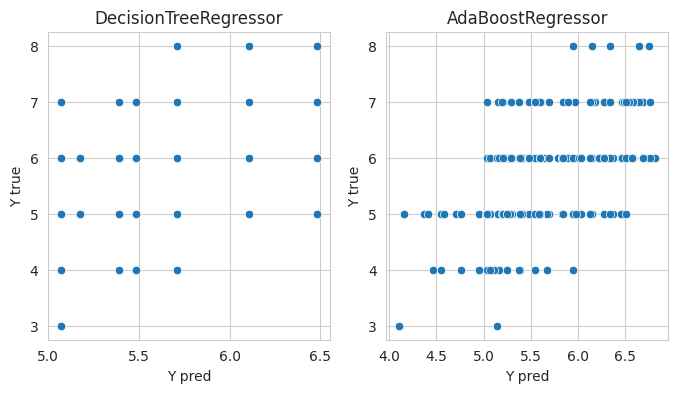

In [96]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))  
sns.scatterplot(x = y_pred_tree_pca, y = y_test, ax=ax[0])
sns.scatterplot(x = y_pred_ada_pca, y = y_test, ax=ax[1])
ax[0].grid(True)
ax[0].set_xlabel('Y pred')
ax[0].set_ylabel('Y true')
ax[0].set_title('DecisionTreeRegressor')

ax[1].grid(True)
ax[1].set_xlabel('Y pred')
ax[1].set_ylabel('Y true')
ax[1].set_title('AdaBoostRegressor')

In [97]:
# Теперь сравним время обучения

In [98]:
tree_pca_time = learn_time(DecisionTreeRegressor, tree_pca_gs.best_params_, X_train_transformed, y_train, n=1000)
ada_pca_time = learn_time(AdaBoostRegressor, ada_pca_gs.best_params_, X_train_transformed, y_train, n=1000)

In [99]:
learn_alg_times_pca = pd.DataFrame({
    "DecisionTreeRegressor": tree_pca_time,
    "AdaBoostRegressor": ada_pca_time
})
learn_alg_times_pca["DecisionTreeRegressor"] *= 1000
learn_alg_times_pca["AdaBoostRegressor"] *= 1000

<Axes: xlabel='AdaBoostRegressor PCA', ylabel='Learn time, ms'>

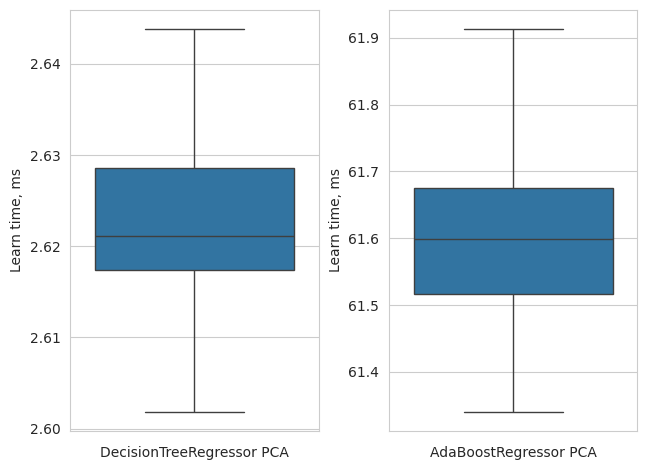

In [100]:
fig, axs = plt.subplots(1, 2)
fig.tight_layout(w_pad=2)

axs[0].set_ylabel("Learn time, ms")
axs[0].set_xlabel("DecisionTreeRegressor PCA")
axs[1].set_ylabel("Learn time, ms")
axs[1].set_xlabel("AdaBoostRegressor PCA")

sns.boxplot(
    y='DecisionTreeRegressor', 
    data=learn_alg_times_pca,  
    showfliers=False,
    ax=axs[0]
)

sns.boxplot(
    y='AdaBoostRegressor', 
    data=learn_alg_times_pca, 
    showfliers=False,
    ax=axs[1]
)

In [101]:
ada_rate =  learn_alg_times.AdaBoostRegressor.mean() / learn_alg_times_pca.AdaBoostRegressor.mean()
tree_rate = learn_alg_times.DecisionTreeRegressor.mean() / learn_alg_times_pca.DecisionTreeRegressor.mean()

In [102]:
ada_rate

0.7625137553323545

In [103]:
tree_rate

0.9085069850239187

In [104]:
scaler = StandardScaler()
scaler.fit(X_train)
x_train_scaled = scaler.transform(X_train)

In [105]:
tree_res = {}
ada_res = {}
for n in range(2, 11):
    pca = PCA(n_components=n)
    pca.fit(X_train)
    x_pca_transformed = pca.transform(x_train_scaled)
    n_comp_time_tree = learn_time(
        DecisionTreeRegressor, 
        tree_pca_gs.best_params_, 
        x_pca_transformed, 
        y_train, 
        n=200
    )
    
    n_comp_time_ada = learn_time(
        AdaBoostRegressor, 
        ada_pca_gs.best_params_, 
        x_pca_transformed, 
        y_train, 
        n=200
    )
    
    tree_res[n] = n_comp_time_tree
    ada_res[n] = n_comp_time_ada

In [106]:
tree_res = pd.DataFrame(tree_res)
mean_time_tree = pd.DataFrame(tree_res.agg('mean'))
mean_time_tree['n_components'] = mean_time_tree.index
mean_time_tree.columns = ['mean_time, ms', 'n_components']
mean_time_tree['mean_time, ms'] *= 1000

In [107]:
ada_res = pd.DataFrame(ada_res)
mean_time_ada = pd.DataFrame(ada_res.agg('mean'))
mean_time_ada['n_components'] = mean_time_ada.index
mean_time_ada.columns = ['mean_time, ms', 'n_components']
mean_time_ada['mean_time, ms'] *= 1000

Text(0.5, 1.0, 'AdaBoostRegressor learning time')

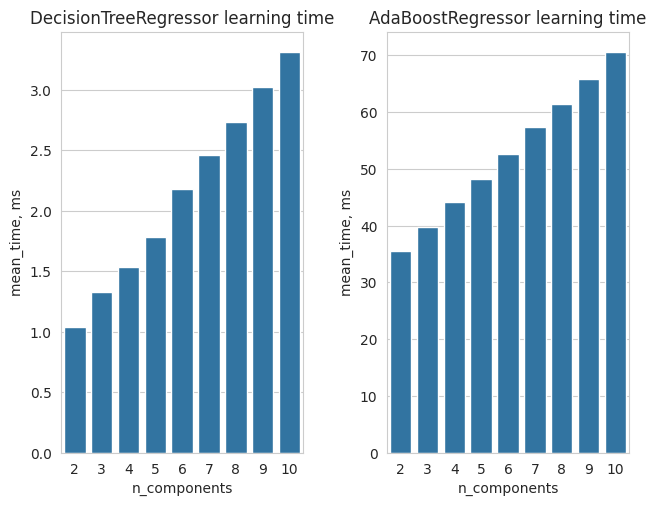

In [108]:
fig, axs = plt.subplots(1, 2)  
fig.tight_layout(w_pad=3)

sns.barplot(data=mean_time_tree, x='n_components', y='mean_time, ms', ax=axs[0])
sns.barplot(data=mean_time_ada,  x='n_components', y='mean_time, ms', ax=axs[1])
axs[0].set_title("DecisionTreeRegressor learning time")
axs[1].set_title("AdaBoostRegressor learning time")

Уменьшение количества признаков линейно синижает время обучения для обоих алгоритмов.

## Сравнение результатов

Сравните результаты полученные до трансформации данных с помощью PCA и после. Для этого воспользуйтесь "ящиком с усами" (boxplot).

Сделайте общие итоговые выводы о моделях регрессии с точки зрения их работы с признаками и сложности самой модели (какие гиперпараметры есть у модели, сильно ли изменение значения гиперпараметра влияет на качество модели).

In [109]:
n1 = len(learn_alg_times)
n2 = len(learn_alg_times_pca)

dt_time_ = pd.DataFrame({
    "time, ms": learn_alg_times.DecisionTreeRegressor.tolist() + learn_alg_times_pca.DecisionTreeRegressor.tolist(),
    "pca": [False for _ in range(n1)] + [True for _ in range(n1)] 
})

ada_time_ = pd.DataFrame({
    "time, ms": learn_alg_times.AdaBoostRegressor.tolist() + learn_alg_times_pca.AdaBoostRegressor.tolist(),
    "pca": [False for _ in range(n1)] + [True for _ in range(n1)] 
})

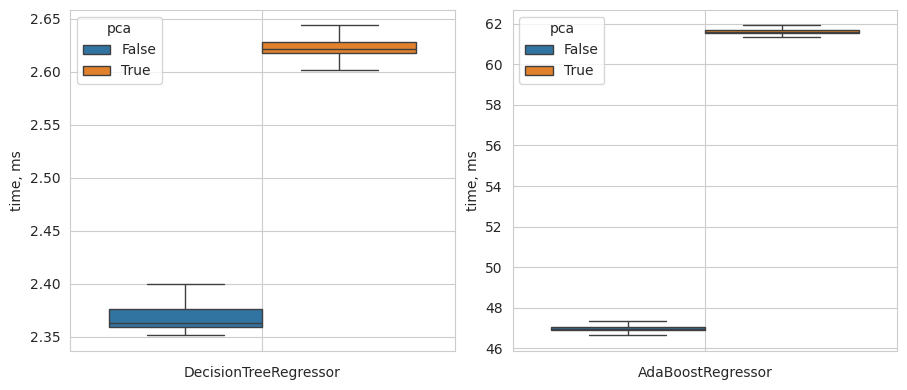

In [110]:
fig, axs = plt.subplots(1, 2, figsize=(9,4))
fig.tight_layout()

sns.boxplot(data=dt_time_, y="time, ms", hue="pca", showfliers=False, ax=axs[0])
sns.boxplot(data=ada_time_, y="time, ms", hue="pca", showfliers=False, ax=axs[1])
axs[0].set_xlabel("DecisionTreeRegressor")
axs[1].set_xlabel("AdaBoostRegressor")
axs[0].grid(True)
axs[1].grid(True)

Получили результат, противоречащий интуиции - признаков меньше, а время обучения дольше. На самом деле все логично.
Наши изначальные данные конечно не дискрентые, но все таки некоторые стобцы содержат не так много значений.
Дереву, для того чтобы выбрать порог для дальнейшего разделения выборки нужно перебрать все возможные пороги для каждого признака.
После PCA преобразования признаков стало меньше, но количество уникальных значений стало больше. Проверим, что это действительно так.

In [111]:
# столбец, соответствующий residual sugar - всего 79 значений
np.unique(X_train[:,3]).shape

(79,)

In [112]:
# возьмем любой столбец данных PCA - количество уникальных значений ровно такое же, как и количество наблюдений в датасете
np.unique(X_train_transformed[:,4]).shape

(951,)

### Деревья и важности признаков

In [113]:
# Посмотрим, как же выглядит наше дерево

In [114]:
from sklearn.tree import plot_tree

[Text(0.5978260869565217, 0.9166666666666666, 'x[10] <= 11.033\nsquared_error = 0.678\nsamples = 951\nvalue = 5.624'),
 Text(0.3695652173913043, 0.75, 'x[9] <= 0.675\nsquared_error = 0.489\nsamples = 696\nvalue = 5.397'),
 Text(0.17391304347826086, 0.5833333333333334, 'x[10] <= 10.15\nsquared_error = 0.41\nsamples = 489\nvalue = 5.254'),
 Text(0.08695652173913043, 0.4166666666666667, 'x[1] <= 0.752\nsquared_error = 0.336\nsamples = 352\nvalue = 5.156'),
 Text(0.043478260869565216, 0.25, 'squared_error = 0.291\nsamples = 306\nvalue = 5.212'),
 Text(0.13043478260869565, 0.25, 'x[3] <= 2.15\nsquared_error = 0.474\nsamples = 46\nvalue = 4.783'),
 Text(0.08695652173913043, 0.08333333333333333, 'squared_error = 0.514\nsamples = 22\nvalue = 4.409'),
 Text(0.17391304347826086, 0.08333333333333333, 'squared_error = 0.193\nsamples = 24\nvalue = 5.125'),
 Text(0.2608695652173913, 0.4166666666666667, 'x[6] <= 14.5\nsquared_error = 0.513\nsamples = 137\nvalue = 5.504'),
 Text(0.21739130434782608, 0

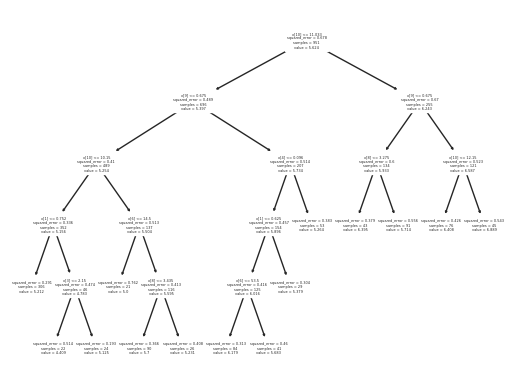

In [115]:
plot_tree(tree)

In [116]:
# Посмотрим также на пару деревьев из ансамбля

[Text(0.5, 0.875, 'x[10] <= 11.05\nsquared_error = 0.719\nsamples = 951\nvalue = 5.645'),
 Text(0.25, 0.625, 'x[9] <= 0.655\nsquared_error = 0.509\nsamples = 684\nvalue = 5.386'),
 Text(0.125, 0.375, 'x[1] <= 0.663\nsquared_error = 0.408\nsamples = 438\nvalue = 5.194'),
 Text(0.0625, 0.125, 'squared_error = 0.345\nsamples = 320\nvalue = 5.294'),
 Text(0.1875, 0.125, 'squared_error = 0.477\nsamples = 118\nvalue = 4.924'),
 Text(0.375, 0.375, 'x[4] <= 0.097\nsquared_error = 0.507\nsamples = 246\nvalue = 5.728'),
 Text(0.3125, 0.125, 'squared_error = 0.416\nsamples = 190\nvalue = 5.9'),
 Text(0.4375, 0.125, 'squared_error = 0.372\nsamples = 56\nvalue = 5.143'),
 Text(0.75, 0.625, 'x[9] <= 0.675\nsquared_error = 0.647\nsamples = 267\nvalue = 6.307'),
 Text(0.625, 0.375, 'x[8] <= 3.275\nsquared_error = 0.54\nsamples = 150\nvalue = 5.993'),
 Text(0.5625, 0.125, 'squared_error = 0.324\nsamples = 51\nvalue = 6.431'),
 Text(0.6875, 0.125, 'squared_error = 0.502\nsamples = 99\nvalue = 5.768'),
 

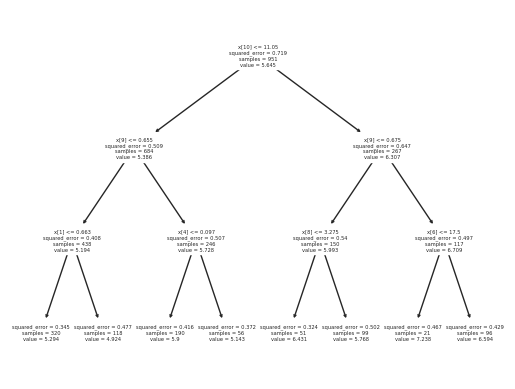

In [117]:
plot_tree(ada.estimators_[0])

[Text(0.5, 0.875, 'x[9] <= 0.635\nsquared_error = 1.699\nsamples = 951\nvalue = 5.566'),
 Text(0.25, 0.625, 'x[5] <= 10.5\nsquared_error = 1.449\nsamples = 512\nvalue = 5.1'),
 Text(0.125, 0.375, 'x[8] <= 3.535\nsquared_error = 1.326\nsamples = 221\nvalue = 4.638'),
 Text(0.0625, 0.125, 'squared_error = 1.17\nsamples = 185\nvalue = 4.843'),
 Text(0.1875, 0.125, 'squared_error = 0.799\nsamples = 36\nvalue = 3.583'),
 Text(0.375, 0.375, 'x[10] <= 11.35\nsquared_error = 1.258\nsamples = 291\nvalue = 5.45'),
 Text(0.3125, 0.125, 'squared_error = 1.067\nsamples = 241\nvalue = 5.249'),
 Text(0.4375, 0.125, 'squared_error = 1.044\nsamples = 50\nvalue = 6.42'),
 Text(0.75, 0.625, 'x[10] <= 10.525\nsquared_error = 1.441\nsamples = 439\nvalue = 6.109'),
 Text(0.625, 0.375, 'x[0] <= 10.95\nsquared_error = 1.103\nsamples = 185\nvalue = 5.524'),
 Text(0.5625, 0.125, 'squared_error = 0.946\nsamples = 148\nvalue = 5.284'),
 Text(0.6875, 0.125, 'squared_error = 0.574\nsamples = 37\nvalue = 6.486'),
 T

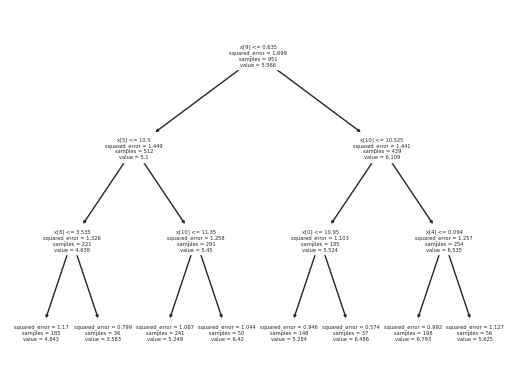

In [118]:
plot_tree(ada.estimators_[7])

In [119]:
# Посмотрим, как деревья взаимодействуют с компонентами. Для этого построим графики важности признаков.
# Для ансамбля деревьев усредним важности признаков.

In [120]:
ada_feature_importance = {i: estimator.feature_importances_ for i, estimator in enumerate(ada.estimators_)}
ada_feature_importance = pd.DataFrame(ada_feature_importance).T
ada_feature_importance.columns = columns

In [121]:
ada_feature_importance_pca = {i: estimator.feature_importances_ for i, estimator in enumerate(ada_pca.estimators_)}
ada_feature_importance_pca = pd.DataFrame(ada_feature_importance_pca).T
ada_feature_importance_pca.columns = [f"Компонента {i}" for i in range(1, n_components+1)]

In [122]:
no_pca_feature_importance = pd.DataFrame(tree.feature_importances_).T
no_pca_feature_importance.columns = columns
no_pca_feature_importance = pd.concat((no_pca_feature_importance, pd.DataFrame(ada_feature_importance.mean()).T))
no_pca_feature_importance['model'] = ['DecisionTreeRegressor', 'AdaBoostRegressor']

<Axes: xlabel='value', ylabel='variable'>

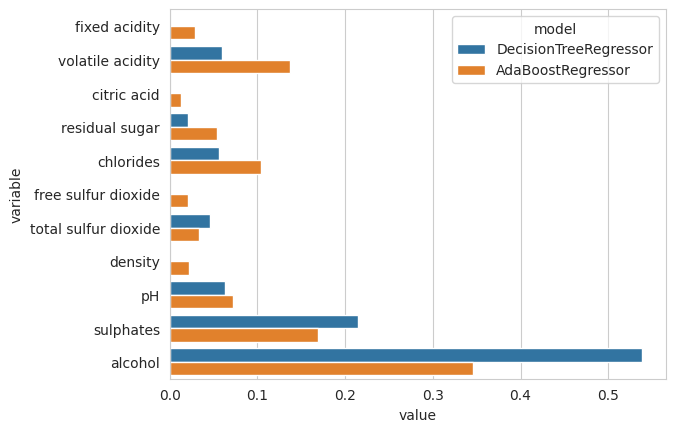

In [123]:
sns.barplot(no_pca_feature_importance.melt(id_vars='model'), hue='model', x='value', y='variable')

In [124]:
pca_feature_importance = pd.DataFrame(tree_pca.feature_importances_).T
pca_feature_importance.columns = [f"Компонента {i}" for i in range(1, 9)]
pca_feature_importance = pd.concat((pca_feature_importance, pd.DataFrame(ada_feature_importance_pca.mean()).T))
pca_feature_importance['model'] = ['DecisionTreeRegressor PCA', 'AdaBoostRegressor PCA']

<Axes: xlabel='value', ylabel='variable'>

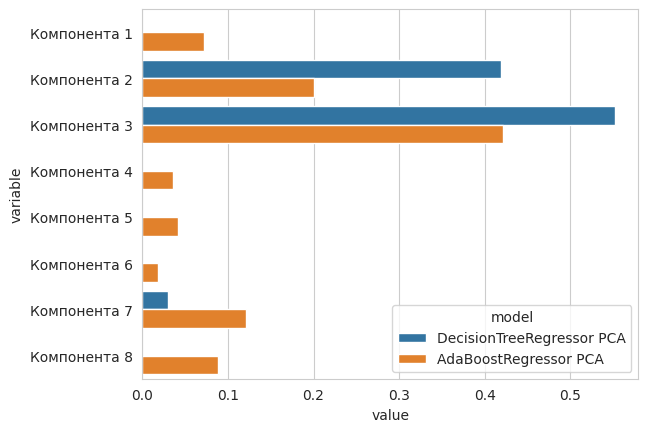

In [125]:
sns.barplot(pca_feature_importance.melt(id_vars='model'), hue='model', x='value', y='variable')

#### Вывод: 
Не всегда снижение размерности приводит к увеличению скорости обучения, иногда можно получить прямо противоположный эффект ввиду особенностей
работы конкретного алгоритма. 
    
Оценить влияние каждого конкретного гиперпараметра сложно, т.к. необходимо учитывать его взаимодействие с другими гиперпараметрами, однако из теории известно, что деревья решений - модель, склонная к переобучению, почти все доступные гиперпапраметры направлены на контроль сложности дерева. Для модели AdaBoostRegressor наиболее существенными параметрами являются количество моделей в ансамбле и learning rate. 

Можно заметить, что между важностью признаков, используемымых DecisionTreeRegressor и AdaBoostRegressor есть корреляция, однако нельзя сказать, что модели повторяют друг друга. Например, в преобразованном с помощью PCA датасете видно, что AdaBoostRegressor использует признаки, которые в DecisionTreeRegressor практически не используются. Также можно сделать вывод, что некоторые признаки несут очень мало информации (или не несут совсем).

## Тестирование всех модели

Протестируйте все построенные модели (в т.ч. с и без PCA трансформации) на данных, которые были отложены для теста (их должно было остаться 30%). Не забудьте про все необходимые преобразования.

In [139]:
# У нас уже есть лог всех проведенных экспериментов с метриками для тестовой части датасета, посмотрим еще раз
res.reset_index(drop=True).style.highlight_min(subset='mse',color = 'lightgreen', axis = 0) 

,model,mse,r2,model_params,ds_info
0,tree,0.656250,-0.012218,default,no_preprocess
1,ada,0.374586,0.422228,default,no_preprocess
2,tree,0.865196,-0.279576,default,clean_outliers
3,ada,0.468448,0.307191,default,clean_outliers
4,tree,0.818627,-0.210704,default,feature_interaction
5,ada,0.452218,0.331194,default,feature_interaction
6,tree,0.530498,0.215423,grid_search,no_preprocess
7,tree,0.518203,0.233607,grid_search,feature_interaction
8,ada,0.456478,0.324894,grid_search,no_preprocess
9,ada,0.462978,0.315282,grid_search,feature_interaction


In [127]:
# В данном проекте нужно было обучить модель регрессии, однако целевой признак также допускает  
# рассмотрение данной задачи как задачи классификации. Проведем эксперимент и обучим классификатор.

In [128]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [129]:
df = pd.read_csv("winequality-red.csv", sep=";")
df.drop_duplicates(keep="first", inplace=True)

X = df.drop(columns="quality").values
y = df["quality"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)

In [130]:
rf = RandomForestClassifier()

In [131]:
rf.fit(X_train, y_train)

RandomForestClassifier()

In [132]:
rf_pred = rf.predict(X_test)

In [133]:
report = classification_report(y_test, rf_pred, output_dict=True)

In [134]:
pd.DataFrame(report)

,3,4,5,6,7,8,accuracy,macro avg,weighted avg
precision,0.0,0.0,0.656566,0.558140,0.428571,0.0,0.590686,0.273879,0.551164
recall,0.0,0.0,0.751445,0.596273,0.300000,0.0,0.590686,0.274620,0.590686
f1-score,0.0,0.0,0.700809,0.576577,0.352941,0.0,0.590686,0.271721,0.567931
support,3.0,16.0,173.000000,161.000000,50.000000,5.0,0.590686,408.000000,408.000000


In [135]:
# Можно сказать, что в такой постановке задачи, RandomForest из коробки дает сравнительно неплохой результат

#### Итоги:
* в некоторых случаях модель совершенно не работает 'из коробки';
* количество признаков существенно влияет на скорость обучения обоих использованных алгоритмов, причем не так, как интуитивно кажется;
* предобработка данных и добавление новых признаков не всегда может улучшить датасет и добавить информативности;
* PCA - эффективный метод снижения размерности, однако его применение не всегда целесообразно;
* не все признаки в деревьях одинаково важны, некоторые вовсе можно исключить из рассмотрения;
* ансамбль показал себя как более эффективный метод, хотя и его качество на данном датасете не слишком высокое: 0,42 - достаточно низкий коэффициент детерминации, а 0,37 - большая ошибка MSE.

Качетсвенную модель регрессии построить не удалось, но были изучены особенности работы DecisionTreeRegressor и ансамбля из деревьев регрессии - AdaBoostRegressor. После всех проведенных экспериментов оказалось, что лучшее качество показала модель AdaBoostRegressor, обученная на параметрах по умолчанию, при этом никаких преобразований датасета, кроме удаления дубликатов не проводилось.